01 Course Overview 

Goal: learn and understand how to train a state of tthe art model 
Process: 
1) Get A Dataset 
2) Train a Model 
3) Test and Evaluate the Model 

Exercises 1 - Python Refresher 
Topics: 
- Datatypes 
- Operations 
- Tensors 
- Functions 
- Iteration 
- Conditionals 
- Classes and Methods 



More on Tensors: 
A tensor is a class supplied by the pytorch library which can create tensor objects. 
Some features of the tensor class: 
1) Have a built in way to take derivatives
2) Can be placed in GPU memory 
3) Tensors are strict with types, and cant force much (cant add double and float)

A tensor can have multiple dimensions, meaning they need more than one index to reference. Some terms and Python data types:

|tensor rank|math term|similar Python thing|
|:-:|:-:|:-:|
|0|scalar|`float`|
|1|vector|`list`|
|2|matrix|Pandas `Dataframe`|
|3+|tensor|PyTorch `Tensor` (also for lower ranks)|

Going to do a quick example of some Object Oriented Programming to reference in the futue 

In [39]:
class Counter:

    def __init__(self: "Counter", starting_val: int=1) -> "Counter":
        self.val = 0
        self.starting_val

    def countone(self: "Counter") -> "Counter":
        self.val += 1
        print(self.val)
        return self

    def count(self: "Counter", howmany: int) -> "Counter":
        for i in range(howmany):
            self.countone()
        return self

    def reset(self: "Counter") -> "Counter":
        self.val = 0
        return self

    def __str__(self: "Counter") -> str:
        return f"Counter current value: {self.val}"

Overview:

We have a class called Counter.

It has 2 attributes 
.val 
.starting_val

It has 5 different methods. 
__init__ - initilizaes the calss with its value and starting value 
countone - takes an object of the class an an arg and references its value attribute and adds 1 to it. It then returns the object.
count - take argument of class object as well as a varibale called howmany and adds the howmany value to the value of the class object 
reset - this takes the object and sets its value attribute to 0 



02 Crash Course in Machine Learning 

Vocab: 

batch - we can split the training of the model into batches to combat memory as time constraints 
loss function - an error function
epoch = the number of times we train the model over the whole dataset 
gradient descent = a method for finding local/global minima of a loss function 
hyperparameter = a list of inputs to the model that are not changed at training time (lr and decay)
y_hat = mx + b , here y_hat is the response, x is the predictor / variable, m and b are the parameters/weights
model = a general function which we are fitting. for example, 
y_hat = mx + b is simple linear model but could also be something like 
y_hat = a1x1 + a2x2^2 + ... + anxn^n + b 
 - note in the above, ai, b are the parameters while xi are the predictors

overfitting - this is an issue where we fit our model to the training data very well but it generalizes very poorly. i.e we underestimate the generalization error because we overfit to the training model. More complex/flexible/ models with more parameters have issues with overfitting. 

training/validation/test set - Models are trained on the training data. Evaluated using the validaton set. We can do furter validation on the testing set. 

Below is a good worked example 

In [40]:
import pandas as pd 
import matplotlib.pyplot as plt 

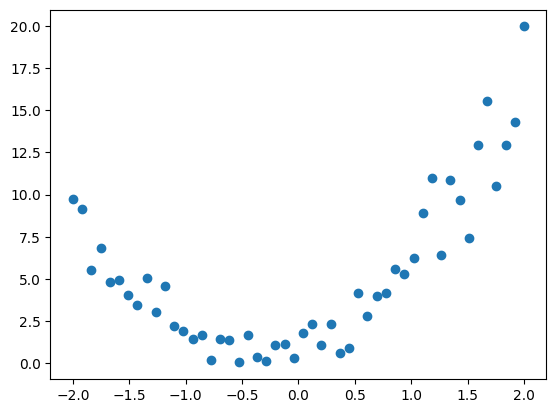

In [41]:
data = pd.read_csv("https://raw.githubusercontent.com/Greg-Hallenbeck/class-datasets/main/datasets/ml_sampledata.csv")
x,y = data["x"], data["y"]

plt.scatter(x, y)
plt.show()

Just based on visual analysis alone, we can see that the relationship between the x and y is basically a parabola. Since we can see this we are going to use a quadratic function to fit the model to. 

i.e. fitting the model to the function;
y_hat = ax^2 + bx + c 

First thing were going to do is set up the model to be fit. <br>
Secondly were going to create the loss function. There are quite a few different loss functions which we run into. Here is an overview 

|Name|Math (Single Point)|Python (Single Point) |a.k.a.|Used For|
|:-:|:-:|:-:|:-:|-:|
|Mean Squared Error (MSE)|$(y-\hat{y})^2$|`(y-yhat).pow(2)`|$\text{L}_2$ Loss|Regression|
|Mean Absolute Deviation (MAD)|$(y-\hat{y}).abs$|`(y-yhat).abs()`|$\text{L}_1$ Loss|Regression|
|Cross-Entropy|$-p\ln\hat{p}$|`p*torch.ln(phat)`|Logistic Loss|Classification|
|Sparse Categorical Cross-Entropy|$-\sum_i p_i \ln \hat{p}_i$|`torch.sum(p*torch.ln(phat))`||Classification|

<br>
Thirdly, we need to implement gradient descent into our code. Basically what gradient descent is doing is finding the minimum of a function. We look at the gradient of the loss function w/ respect to our parameters, and figure out how they must change to move in the direction of the negative gradient/down the hill <br>

Overview of the process:
0) declare the hyperparameter, the two we are focused on are the number of epochs and the learning rate, $\lambda$
1) Start with random parameters (a,b,c) <br>
2) Calculate the loss @ those parameters as well as the gradient of the loss <br>
3) using the gradient of the loss we are basically moving our parameters with respect to the loss, i.e for each parameter, w, w=w-$\lambda * grad_w$ <br>
4) one epoch complete? Repeat this process of 2 and 3 until we minimize our loss with something reasonable (must mitigate the risks of overfitting etc)



In [42]:
import torch

def model(x,a,b,c):
    return a*x.pow(2)+b*x+c

def loss(y,y_hat):
    return (y-y_hat).pow(2).mean()

#converting x and y into tensors 

x = torch.tensor(data['x'].values)
print(x.size())
y = torch.tensor(data['y'].values)

#initialize the random parameters 

#we use tensors so that it is easier for us to take the gradient of the loss with respect to the param.
#in pytorch we have to make note that our params will need to require gradient later

a = torch.rand(1).requires_grad_()
b = torch.rand(1).requires_grad_()
c = torch.rand(1).requires_grad_()

#hpyer parameter
lr = .01 
epochs = 15

#using our random parameter we can calculate the loss 
yhat = model(x,a,b,c)
print(yhat)
print(yhat.size())
 #what we are returned here is a tensor where each cell is ax^2 + bx + c for a specific c. 
#basically we are repeatedly caling the model function on the different x values in the data. 
#Note that the size of both x and the yhat are the same since for each x we get a y when plugging it 
# #into our y_hat = f(x) = ax^2 + bx + c

#Now that we have computed the yhat for our random parameter we calculate the loss/ the error 
#which we incur on the difference betweem the y_hat we predicted and the actual y_hat in the data
#this will give us an idea of where we have to adjust the parameters to move the loss towards a minimum 

J = loss(y,yhat) #note that this is going to return us a difference tensor of size 50 which we take
#the average over
print(J) #this is the average loss over the size 50 difference vector

#calculates the gradient of the loss 
J.backward()

#basicaly telling pytorch we dont want to mess with the gradient
with torch.no_grad():
    a -= lr*a.grad #a = a - lr*a.grad, note a.grad == dJ/da
    b -= lr*b.grad
    c -= lr*c.grad

#then we reset the gradients to zeo for a new round of calculation 
a.grad.data.zero_()
b.grad.data.zero_()
c.grad.data.zero_()

#now we have adjusted our parameters and can see if it has effected the loss of our model
yhat = model(x,a,b,c)
J = loss(y,yhat)
print(J)

#notice our loss before was bigger than our loss after 

torch.Size([50])
tensor([ 2.7582,  2.4903,  2.2357,  1.9943,  1.7662,  1.5514,  1.3499,  1.1617,
         0.9867,  0.8250,  0.6766,  0.5414,  0.4196,  0.3110,  0.2157,  0.1336,
         0.0649,  0.0094, -0.0328, -0.0617, -0.0774, -0.0798, -0.0689, -0.0447,
        -0.0072,  0.0435,  0.1075,  0.1848,  0.2754,  0.3792,  0.4963,  0.6267,
         0.7704,  0.9273,  1.0975,  1.2810,  1.4778,  1.6879,  1.9112,  2.1478,
         2.3977,  2.6609,  2.9373,  3.2270,  3.5300,  3.8463,  4.1758,  4.5186,
         4.8747,  5.2441], dtype=torch.float64, grad_fn=<AddBackward0>)
torch.Size([50])
tensor(24.6703, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(21.3897, dtype=torch.float64, grad_fn=<MeanBackward0>)


Here is a Quickstart Workflow 

In [43]:
def model(w,x):
    return w[0]*x.pow(2)+w[1]*x+w[2]

def loss(y,y_hat):
    return (y-y_hat).pow(2).mean()

## Get the data
x = torch.tensor(data["x"].values)
y = torch.tensor(data["y"].values)

# Initialize parameters
w = torch.rand(3, requires_grad=True)

# Choose hyperparameters
lr = 0.01
num_epochs = 1000

# Keep track of the losses
losses = []

for e in range(num_epochs):
    # Calculate the predicted values
    yhat = model(w, x)

    # Calculate Loss
    J = loss(y, yhat)
    losses.append(float(J))

    # Update weights
    J.backward()
    with torch.no_grad():
        w.sub_(lr*w.grad)
    w.grad.data.zero_()

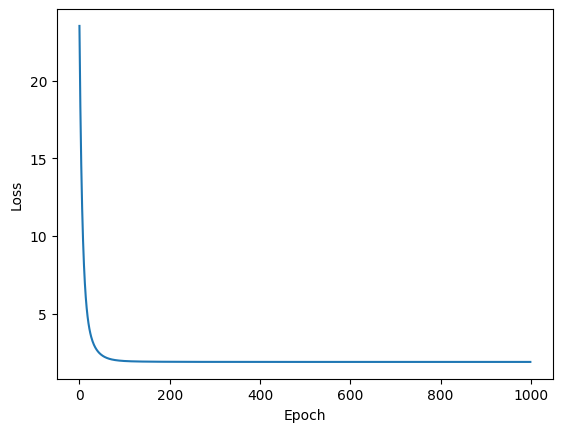

In [48]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.yscale("log")
plt.show()

Some Problems well run into: <br>
1) With large datasets, calculating the loss will take a long time<br>
2) The datasets may be too large to fit into the computers memory<br>


Stochastic Gradient Descent: <br>
Approximating the Loss: Calculating the loss for a single random observation. So our loss function is just $(y_i-\hat{y_i})^2$ for a random observation in our $D_i = (x_i,y_i)$

Then we adjust parameters based off of our J approximation. 

Mini-Batch Gradient Descent: 
Approximating the Loss: Caluclating the loss for a small subset of random observations rather than over the entire training set 

Side-Note: Bias-Variance Trade-Off

Bias: Error on the Training Set
Varience: Additional error on the validation sets, relative to the error on the training set 

Overfit = Low Bias but High Varience 
Simpler Models = High Bias, Low Varience 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Bias_and_variance_contributing_to_total_error.svg/1280px-Bias_and_variance_contributing_to_total_error.svg.png" width="600px">



Exercises 2: 

Gradient descent with momentum:

Similar to the training process we leared before except the way which we adjust the variables are different. Now, <br> 

Note that v is the moemntum term. and both $\beta$ and $\lambda$ are hyperparameters

$$v_{\text new} = \beta*v + (1-\beta)\ J_{\text w_{grad}} $$
$$w_{\text new} = w - \lambda * v_{\text new} $$

03 From Linear Regression to Neural Networks 

Vocab Terms: 

activation function = a function that is used between the layers of a neural network (these functions are always non linear) <br>
hidden layer = intermediate layers of a neural network <br>
neuron =  a single node of a neural network, that involves some input and an output activation <br>
output layer = The last later of a neural network which produces $\hat{y}$ values <br>
neural network =  a series of interconnected layers of neurons. An input layer, n hidden layers, and an output layer <br>

ReLU = the standard activtion function. Rectified Linear Unit. It is simply the line $y=x$ except, 
its 0 when x<0

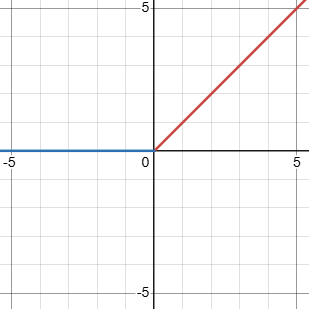

Important Note: Workaround for categorical variables. We can use pd.get_dummies function to one-hot encode categorical variable columns 

Human Readable Metrics: The loss function exists more to help the model fit than it is a human readable metrix. Instead we are interested in residual mean standard error. we use torch.std(y-yhat).

A Residual Plot: Ideally we want the residuals to be horizontal line centered at an eror of zero. (think of the residuals as the $y-\hat{y}$)

Evenly Distributed but not a great error rate (but no trends we need to correct for, just the model in general):

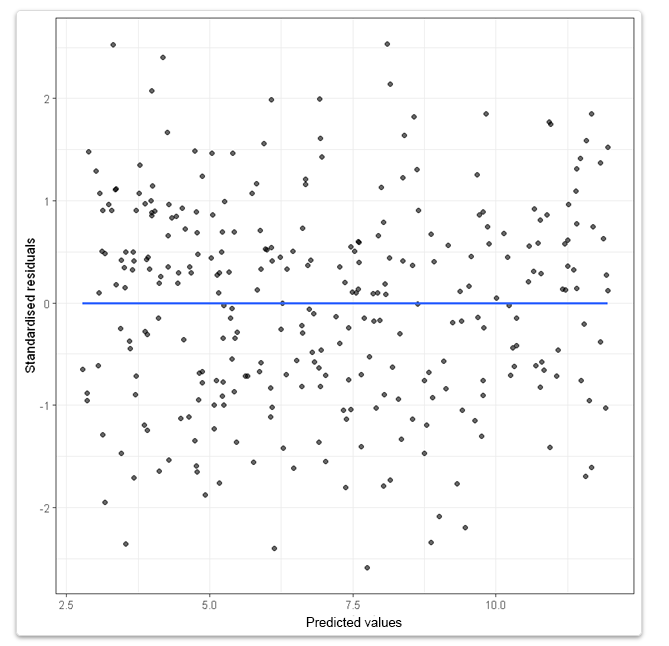

Some residual plots we may encounter 

1) homoscedasticity - the spread of points across the predicted values are not the same 
- fix (could apply a transformation of response variable)

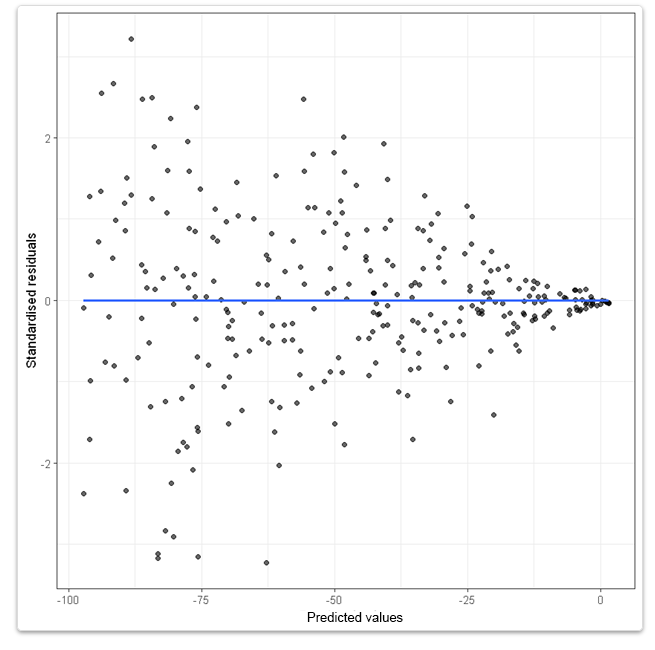

2) non-linearity - the points are not randomly scattered, follow some sort of curvaturs 
-fix (try and locate ind var with non-linear relationship )

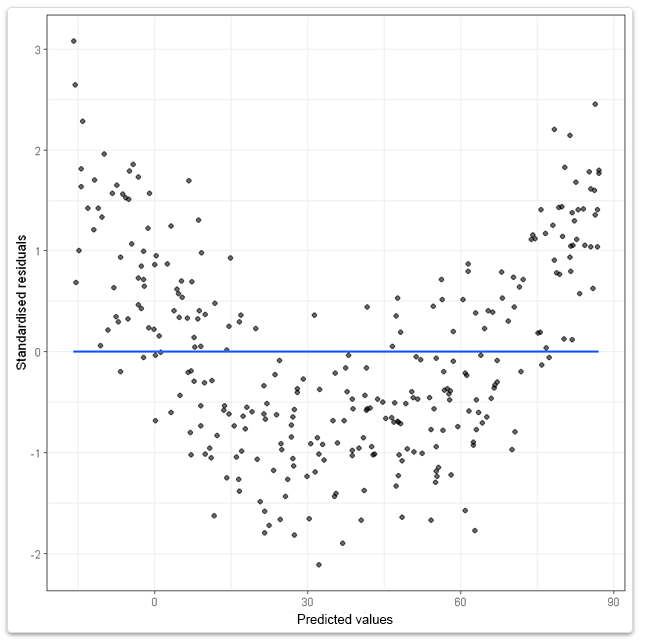

Now, How are we going to move from Lineare Regression and Learning in that Context to Something like a Neural Network. <br> 

So now were fitting to a model we dont know. For example, previously we fit a linear and a quadratic but now we are in a situation where maybe the relationship between the two variables isnt very clear. We could do something like a neural nework. 

It is important to pick an activation function that isn't linear. More specifically want functions that combine to generate new functions. In our interpretation quadratic functions would be linear. 

